##### Load dataset

In [175]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [176]:
original_dataset = pd.read_csv("googleplaystore_dataset.csv")
df = original_dataset.copy()

In [177]:
df.shape

(10841, 13)

##### Dataset has:

- 10841 rows
- 13 columns

##### Overview of the dataset 

In [178]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [179]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


##### Data Cleaning

In [180]:
# check missing values

df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [195]:
# drop null values

df.dropna(inplace=True)

df.isnull().sum()

App                    0
Category               0
Rating                 0
Reviews                0
Size                   0
Installs               0
Type                   0
Price                  0
Content Rating         0
Genres                 0
Last Updated           0
Current Ver            0
Android Ver            0
Size_MB                0
Update_Year            0
Update_Month           0
Days_Since_Update      0
App_Name_Length        0
Num_Genres             0
Is_Free                0
Reviews_per_Install    0
Log_Installs           0
Log_Reviews            0
Log_Price              0
Price_Tier             0
Install_Bucket         0
dtype: int64

##### Feature Engineering and Transformation

In [181]:
# Reviews: string -> int

df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [182]:
# Installs: "10,000+" -> 10000

df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [183]:
# Price: "$4.99" -> 4.99

df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [184]:
# Size: "19M" -> 19.0 (MB), "14k" -> 0.014 (MB), "Varies with device" -> NaN

def parse_size(x):
    x = str(x).strip()
    if x in ('Varies with device', 'nan'):
        return np.nan
    if x.endswith('M'):
        return float(x[:-1])
    if x.endswith(('k', 'K')):
        return float(x[:-1]) / 1024.0
    try:
        return float(x)
    except ValueError:
        return np.nan

df['Size_MB'] = df['Size'].apply(parse_size)
df['Size_MB'] = df.groupby('Category')['Size_MB'].transform(lambda s: s.fillna(s.median()))
df['Size_MB'] = df['Size_MB'].fillna(df['Size_MB'].median())

In [185]:
# Dates

df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df['Update_Year']  = df['Last Updated'].dt.year
df['Update_Month'] = df['Last Updated'].dt.month
df['Days_Since_Update'] = (df['Last Updated'].max() - df['Last Updated']).dt.days

In [186]:
# New engineered features

df['App_Name_Length']      = df['App'].str.len()
df['Num_Genres']           = df['Genres'].str.split(';').apply(len)
df['Is_Free']              = (df['Type'] == 'Free').astype(int)
df['Reviews_per_Install']  = df['Reviews'] / df['Installs'].replace(0, np.nan)

In [187]:
# Skew-correcting log transforms (Installs, Reviews, Price are heavily right-skewed)

df['Log_Installs'] = np.log1p(df['Installs'])
df['Log_Reviews']  = np.log1p(df['Reviews'])
df['Log_Price']    = np.log1p(df['Price'])

In [188]:
# Binned/categorical versions for plotting & grouping

df['Price_Tier'] = pd.cut(df['Price'], bins=[-0.01, 0, 2, 10, 50, 500],
                           labels=['Free', 'Cheap(0-2)', 'Mid(2-10)', 'Pricey(10-50)', 'Premium(50+)'])
install_bins   = [0, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e10]
install_labels = ['<1K', '1K-10K', '10K-100K', '100K-1M', '1M-10M', '10M-100M', '100M+']
df['Install_Bucket'] = pd.cut(df['Installs'], bins=install_bins, labels=install_labels)

#### Exploratory Data Analysis - charts and insights

In [189]:
# matplotlib and seaborn settings

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

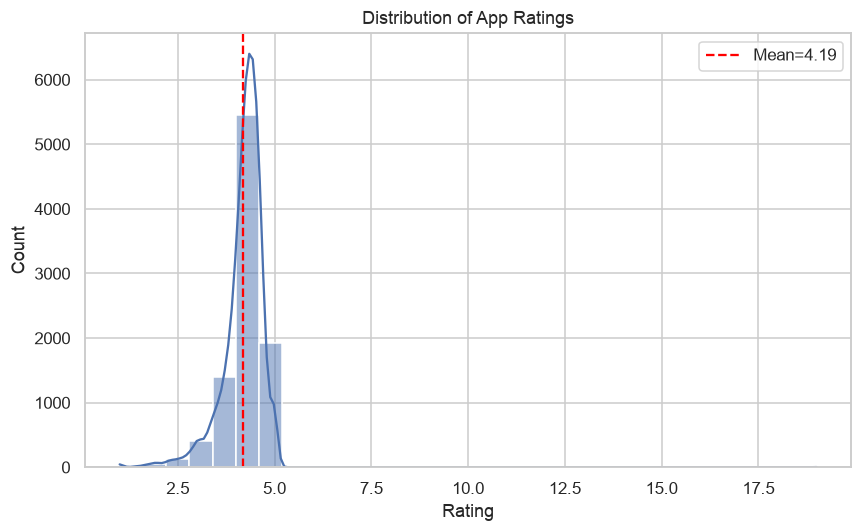

In [190]:
# 1. Distribution of Ratings

plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=30, kde=True, color='#4C72B0')
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', label=f"Mean={df['Rating'].mean():.2f}")
plt.title('Distribution of App Ratings')
plt.xlabel('Rating'); plt.ylabel('Count'); plt.legend()
plt.tight_layout(); 
plt.show()

**Distribution of App Ratings**

- Rating Distribution Insight: 

Ratings are heavily left-skewed. The mean of the distribution seems to be 4.17 and the median is 4.3. Most apps sit between 4.0 and 4.7 and very few apps have ratings below 3.0. This means the Play Store's rating field is not a good discriminator on its own.

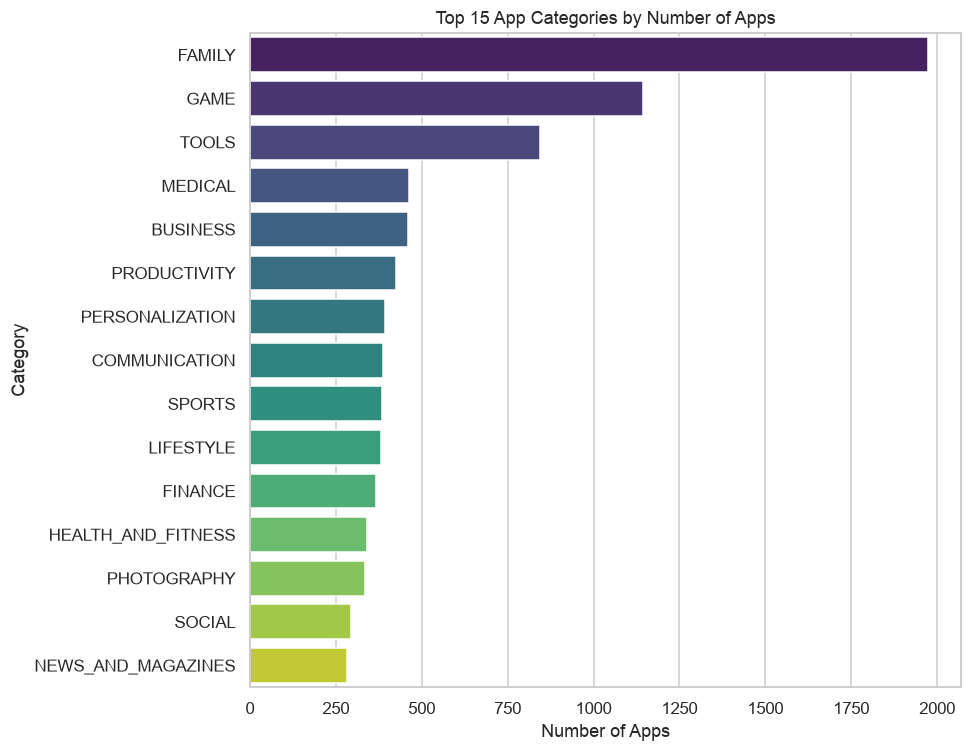

In [191]:
# 2. Top 15 Categories by app count

plt.figure(figsize=(9,7))
cat_counts = df['Category'].value_counts().head(15)
sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index, palette='viridis', legend=False)
plt.title('Top 15 App Categories by Number of Apps')
plt.xlabel('Number of Apps'); plt.ylabel('Category')
plt.tight_layout()
plt.show()

#### Top 15 App Categories by Count

- Top Categories Insight: FAMILY (1,750 apps) and GAME (1100 apps) dominate the store by volume, followed by TOOLS and BUSINESS. The "Family" category is inflated because Google buckets most children's games/education apps there instead of GAME, so category counts should be read with that in mind.

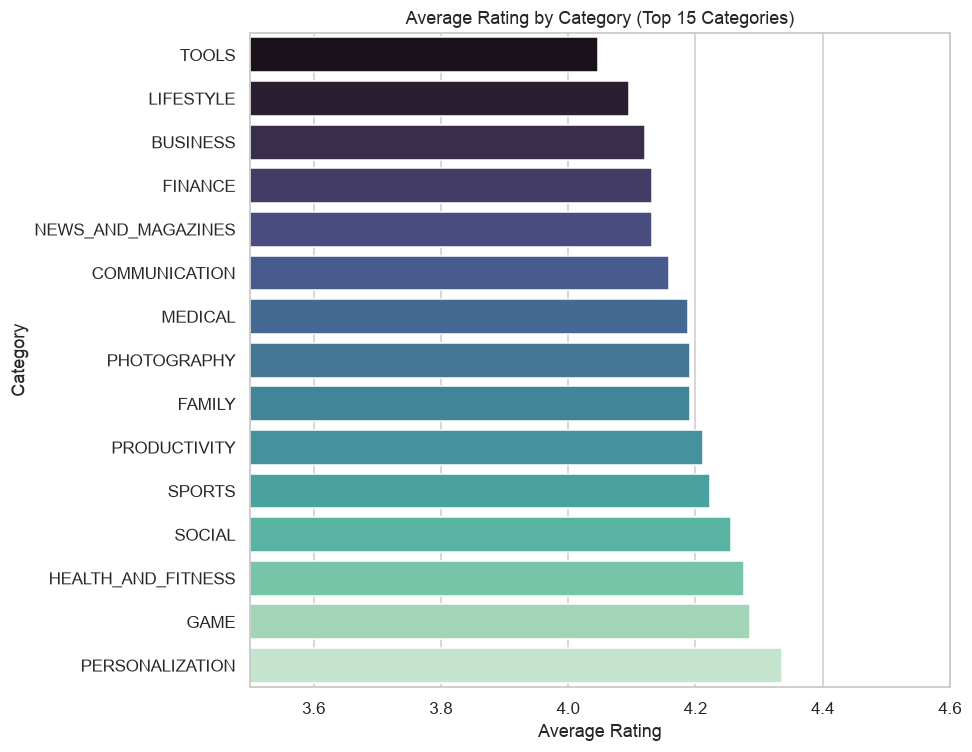

In [192]:
# 3. Average Rating by Category (top 15 by count)

plt.figure(figsize=(9,7))
top_cats = df['Category'].value_counts().head(15).index
avg_rating = df[df['Category'].isin(top_cats)].groupby('Category')['Rating'].mean().sort_values()
sns.barplot(x=avg_rating.values, y=avg_rating.index, hue=avg_rating.index, palette='mako', legend=False)
plt.title('Average Rating by Category (Top 15 Categories)')
plt.xlabel('Average Rating'); plt.ylabel('Category')
plt.xlim(3.5, 4.6)
plt.tight_layout()

##### Average rating by category
**Insight**
Average ratings across categories are tightly clustered (mostly 4.0–4.4). Apps belonging to categories: **Personalization**, **Game**, **Health and Fitness**, **Shopping**, **Social media** and **Productivity** generally get the higher rating (above 4.2) whereas
other categories like **Family**, **Photography**,**Medical**, and so on have 4.0 + ratings but lower than 4.2 

ValueError: 'explode' must be of length 'x', not 2

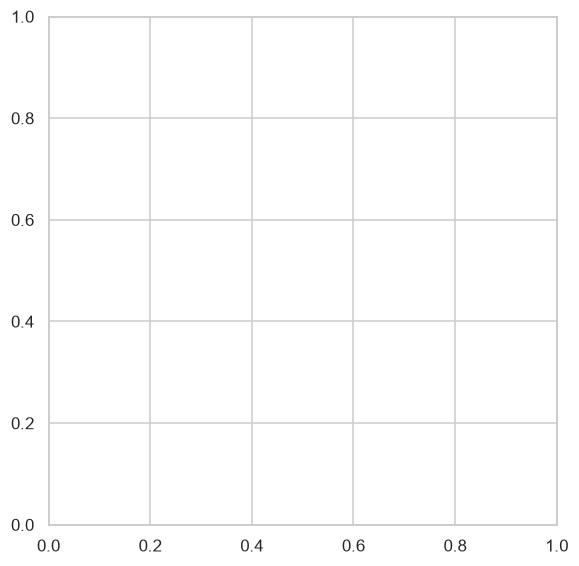

In [193]:
# 4. Free vs Paid count

plt.figure(figsize=(6,6))
type_counts = df['Type'].value_counts()
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#55A868','#C44E52'], startangle=90, explode=[0,0.08])
plt.title('Free vs Paid Apps')
plt.tight_layout()
plt.show()

#### Free vs Paid App
**Insight**
- Free users of the apps clearly dominates the paid ones. There is a huge margin in the number between the free users and paid users. Free users consist of almost 93% + of the total users whereas paid users are very less(only at around 7%) compared to free users. This shows free apps are very popular compared to premium ones in playstore.

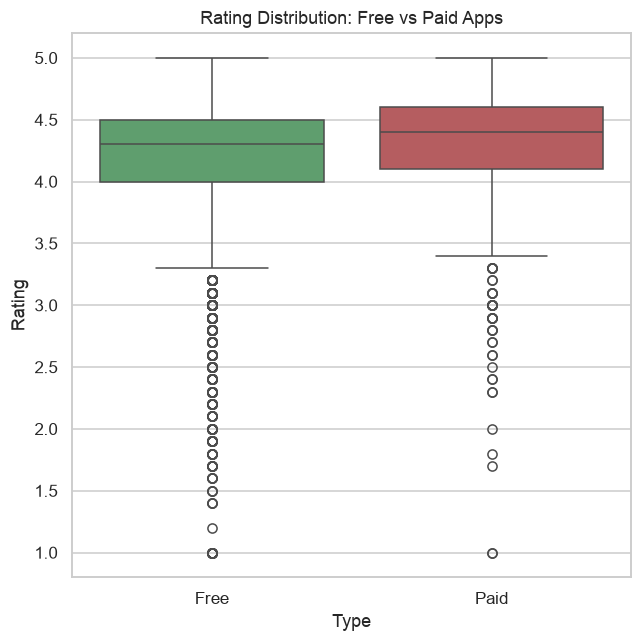

In [ ]:
# 5. Rating: Free vs Paid boxplot

plt.figure(figsize=(6,6))
sns.boxplot(data=df, x='Type', y='Rating', hue='Type', palette=['#55A868','#C44E52'], legend=False)
plt.title('Rating Distribution: Free vs Paid Apps')
plt.tight_layout()

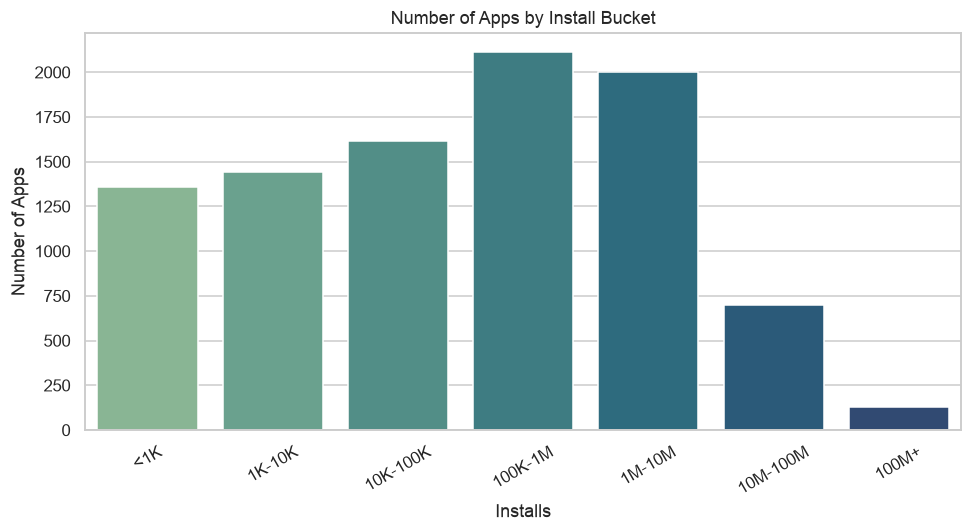

In [ ]:
# 6. Installs distribution by bucket

plt.figure(figsize=(9,5))
order = ['<1K','1K-10K','10K-100K','100K-1M','1M-10M','10M-100M','100M+']
inst_counts = df['Install_Bucket'].value_counts().reindex(order)
sns.barplot(x=inst_counts.index, y=inst_counts.values, hue=inst_counts.index, palette='crest', legend=False)
plt.title('Number of Apps by Install Bucket')
plt.xlabel('Installs'); plt.ylabel('Number of Apps'); plt.xticks(rotation=30)
plt.tight_layout()

**Insight:** 

Installs are extremely skewed: a large share of apps sit in the low-to-mid buckets (1K–1M), while relatively few apps break past 10M+ installs. The Play Store, like most app marketplaces, follows a **power-law / long-tail distribution**, it means a small number of blockbuster apps capture the vast majority of installs.

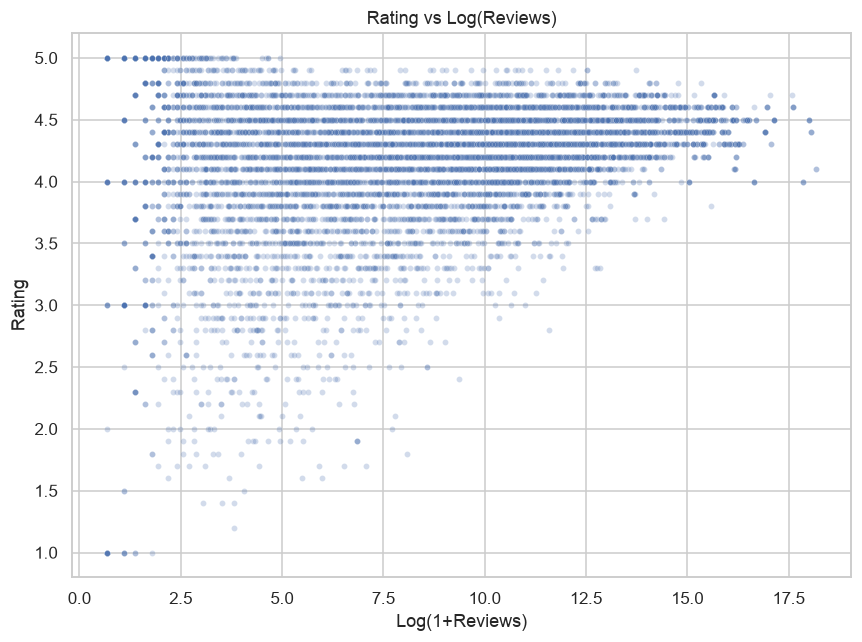

In [ ]:
# 7. Reviews vs Rating scatter (log reviews)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Log_Reviews', y='Rating', alpha=0.25, s=15, color='#4C72B0')
plt.title('Rating vs Log(Reviews)')
plt.xlabel('Log(1+Reviews)'); plt.ylabel('Rating')
plt.tight_layout()

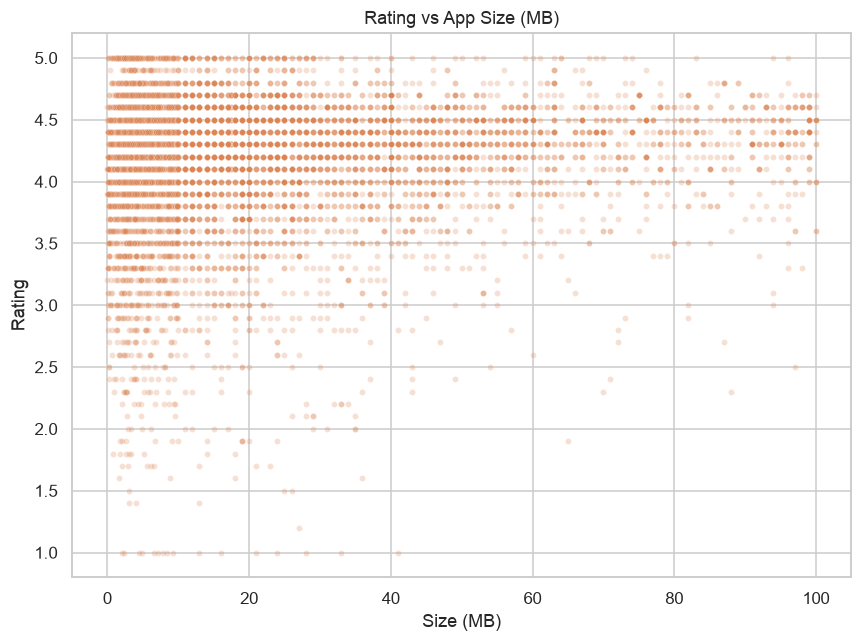

In [ ]:
# 8. Size vs Rating scatter

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Size_MB', y='Rating', alpha=0.25, s=15, color='#DD8452')
plt.title('Rating vs App Size (MB)')
plt.xlabel('Size (MB)'); plt.ylabel('Rating')
plt.tight_layout()

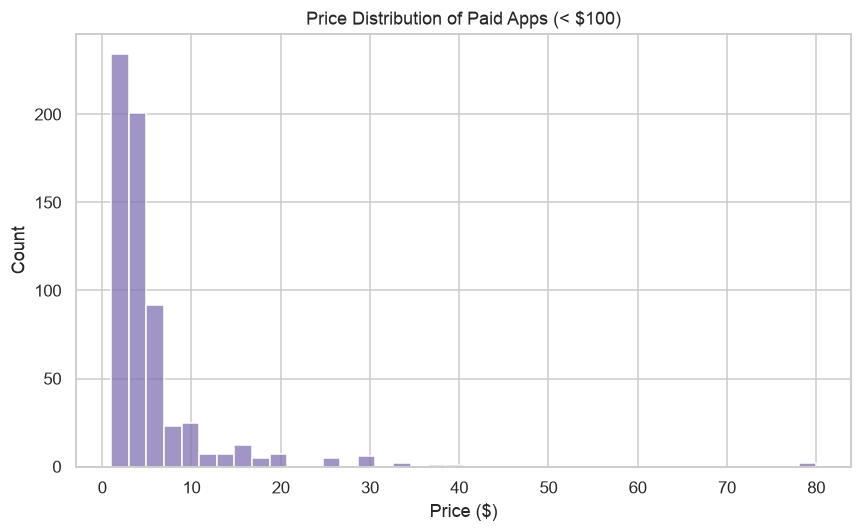

In [ ]:
# 9. Price distribution (paid apps only)

plt.figure(figsize=(8,5))
paid = df[(df['Type']=='Paid') & (df['Price']>0) & (df['Price']<100)]
sns.histplot(paid['Price'], bins=40, color='#8172B2')
plt.title('Price Distribution of Paid Apps (< $100)')
plt.xlabel('Price ($)'); plt.ylabel('Count')
plt.tight_layout()

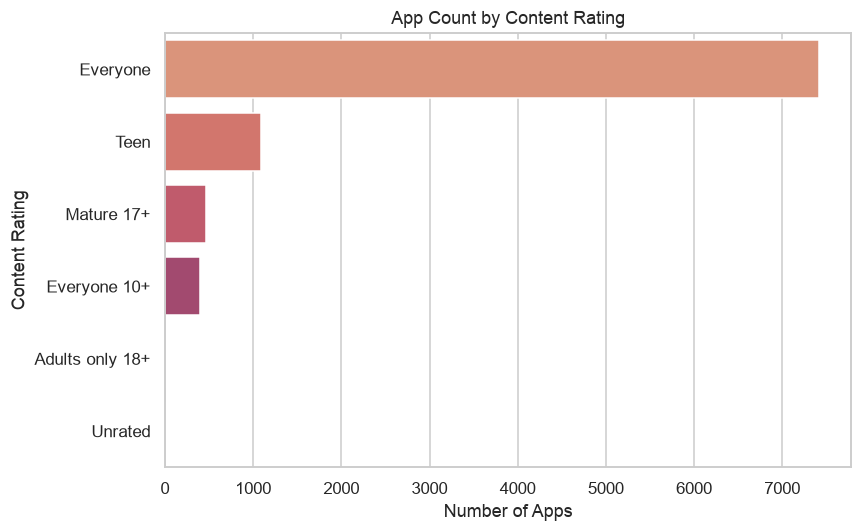

In [ ]:
# 10. Content Rating counts

plt.figure(figsize=(8,5))
cr_counts = df['Content Rating'].value_counts()
sns.barplot(x=cr_counts.values, y=cr_counts.index, hue=cr_counts.index, palette='flare', legend=False)
plt.title('App Count by Content Rating')
plt.xlabel('Number of Apps'); plt.ylabel('Content Rating')
plt.tight_layout()
plt.show()

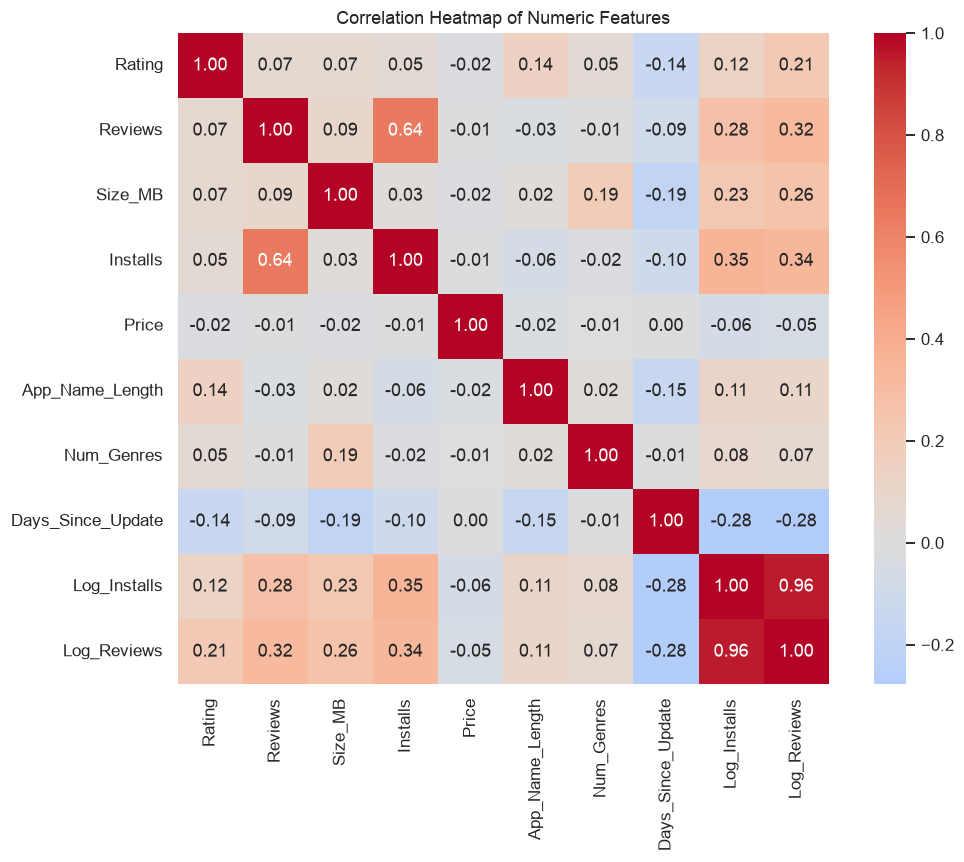

In [ ]:
# 11. Correlation heatmap of numeric features

num_cols = ['Rating','Reviews','Size_MB','Installs','Price','App_Name_Length',
            'Num_Genres','Days_Since_Update','Log_Installs','Log_Reviews']
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()

**Insight:** 

The strongest relationship in the whole numeric feature set is **Reviews ↔ Installs (r≈0.64, or 0.96 in log space)** unsurprising, since more installs mechanically produce more opportunities to review. **Rating correlates weakly with everything** — the highest is `Log_Reviews` (r≈0.18) and the only meaningfully negative one is `Days_Since_Update` (r≈-0.13, apps that haven't been updated recently tend to rate slightly lower). This is an early warning sign that **Rating will be hard to predict accurately from this metadata**.

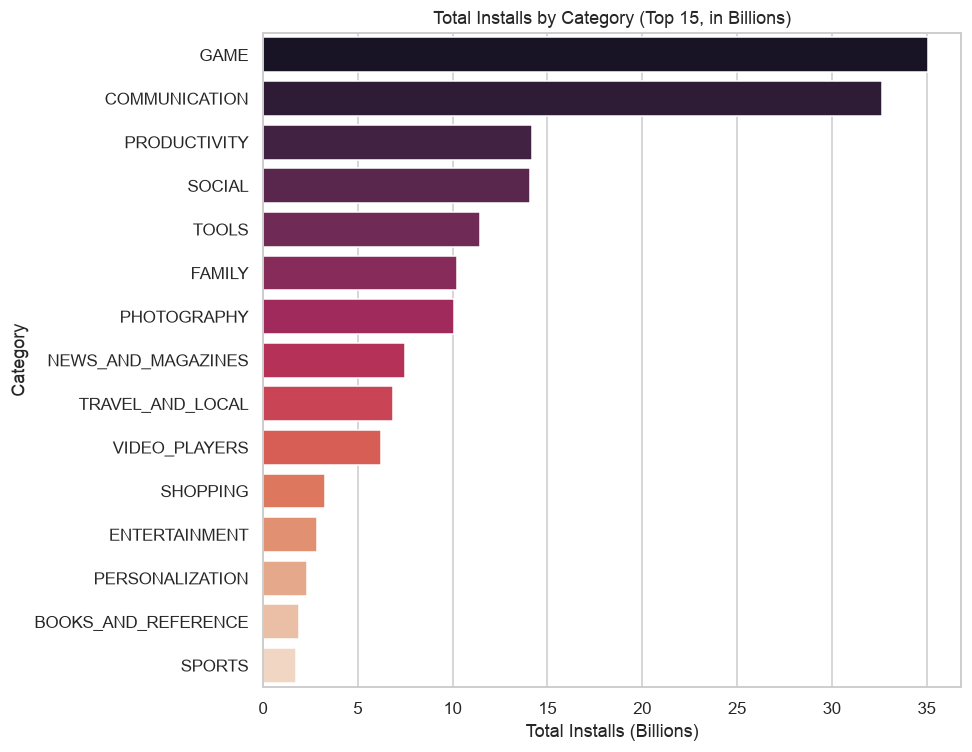

In [ ]:
# 12. Total installs by category (top 15)

plt.figure(figsize=(9,7))
inst_by_cat = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=inst_by_cat.values/1e9, y=inst_by_cat.index, hue=inst_by_cat.index, palette='rocket', legend=False)
plt.title('Total Installs by Category (Top 15, in Billions)')
plt.xlabel('Total Installs (Billions)'); plt.ylabel('Category')
plt.tight_layout()

**Insight:** 

`GAME` (≈35.0B installs) and `COMMUNICATION` (≈32.0B installs) dwarf every other category in total install volume, even though GAME isn't the single largest category by app *count* , a small number of viral games/communication apps (WhatsApp, Messenger, etc.) carry enormous weight.

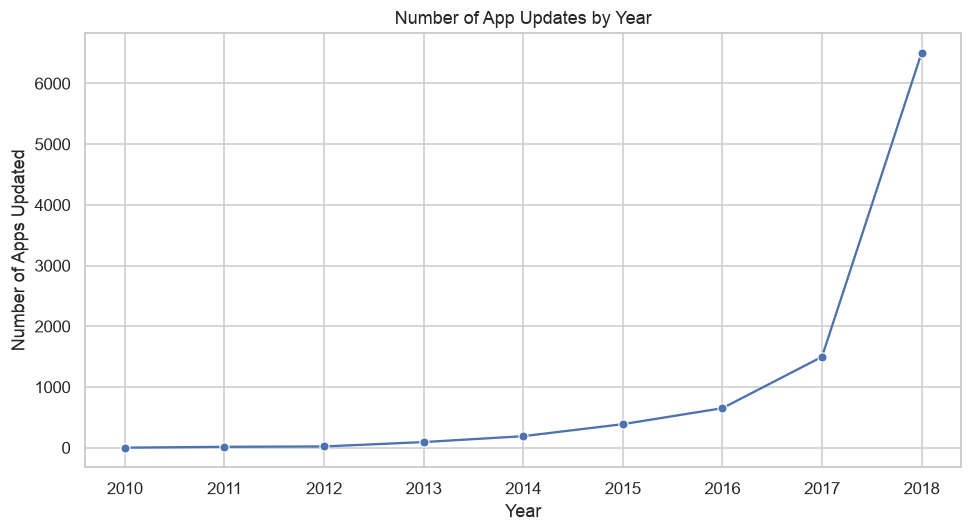

In [ ]:
# 13. App updates over time (by year)

plt.figure(figsize=(9,5))
year_counts = df['Update_Year'].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='#4C72B0')
plt.title('Number of App Updates by Year')
plt.xlabel('Year'); plt.ylabel('Number of Apps Updated')
plt.tight_layout()

**Insight:** 

Update activity ramps up sharply toward **2017-2018**, confirming this dataset was scraped in mid-2018 and that most actively-maintained apps update at least once a year. Very few apps in the dataset were last updated before 2015 — those are effectively **abandoned apps** still listed on the store.

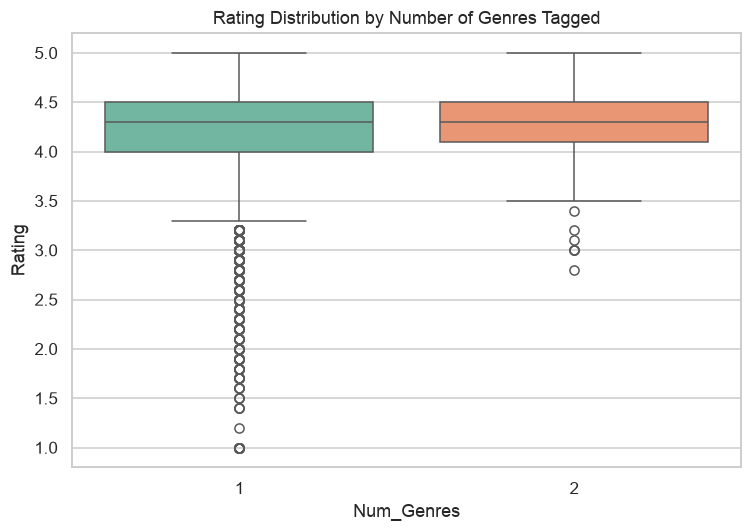

In [ ]:
# 14. Rating by number of genres

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Num_Genres', y='Rating', hue='Num_Genres', palette='Set2', legend=False)
plt.title('Rating Distribution by Number of Genres Tagged')
plt.tight_layout()

**Insight:** 

Apps tagged with 2 genres (e.g., "Action;Adventure") show a marginally higher median rating than single-genre apps, suggesting that cross-genre appeal (or simply more thoughtful store-listing effort) correlates slightly with quality, though the effect is small.

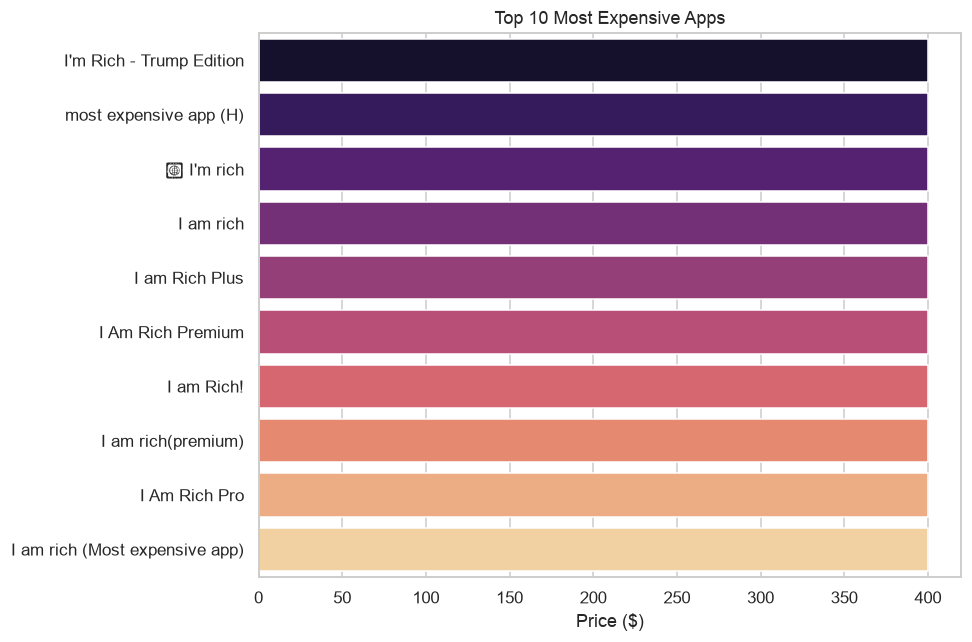

In [ ]:
# 15. Top 10 most expensive apps

plt.figure(figsize=(9,6))
top_price = df.drop_duplicates('App').nlargest(10, 'Price')[['App','Price']]
sns.barplot(x='Price', y='App', data=top_price, hue='App', palette='magma', legend=False)
plt.title('Top 10 Most Expensive Apps')
plt.xlabel('Price ($)'); plt.ylabel('')
plt.tight_layout()

**Insight:** 

The most expensive apps ($399-$400) are almost all **novelty/joke apps** with no real functionality (e.g. status-symbol apps that do nothing but prove you spent money). True high-value utility apps (professional tools, medical references) top out much lower, generally under $100.

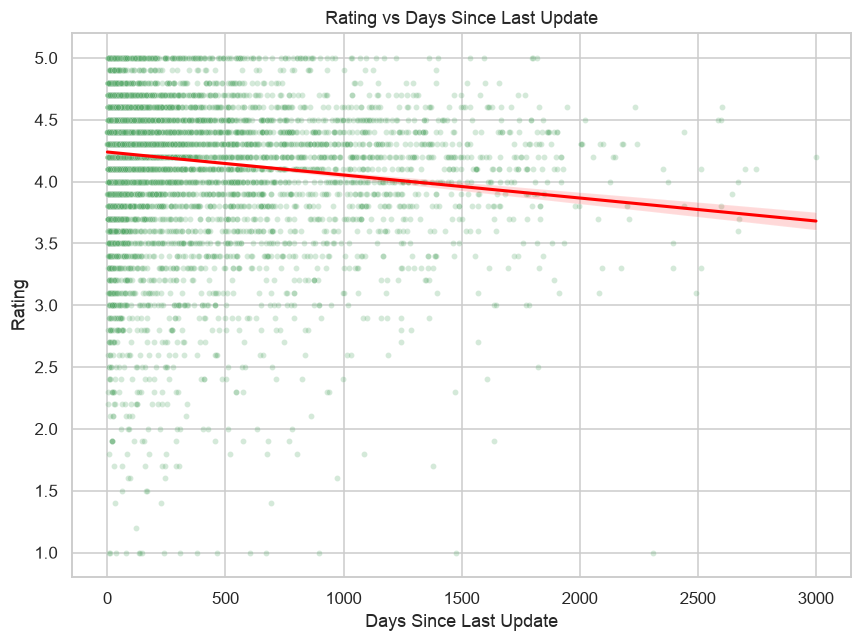

In [ ]:
# 16. Rating vs Days Since Update

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Days_Since_Update', y='Rating', alpha=0.25, s=15, color='#55A868')
sns.regplot(data=df, x='Days_Since_Update', y='Rating', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Rating vs Days Since Last Update')
plt.xlabel('Days Since Last Update'); plt.ylabel('Rating')
plt.tight_layout()

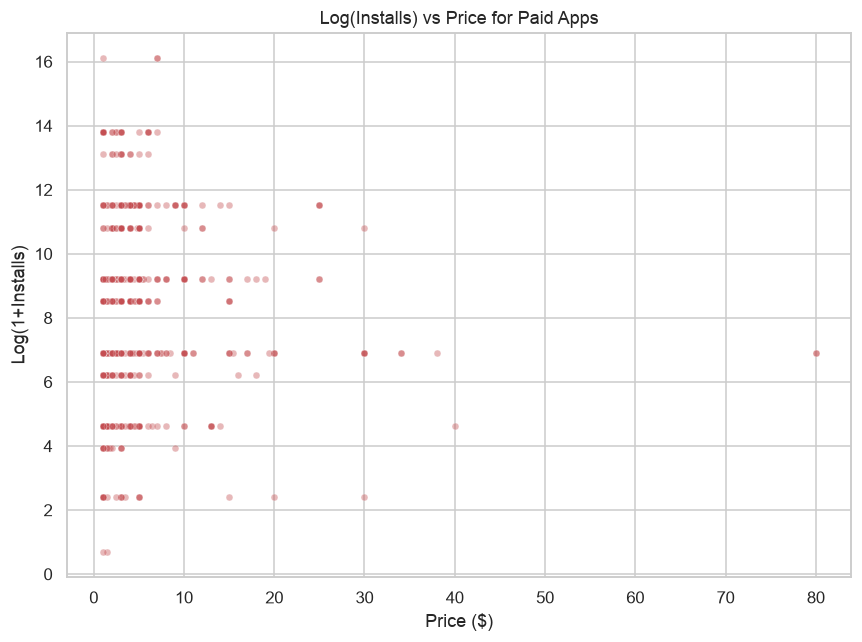

In [ ]:
# 17. Installs vs Price for paid apps (does price hurt installs?)

plt.figure(figsize=(8,6))
paid = df[(df['Type']=='Paid') & (df['Price']>0) & (df['Price']<100)]
sns.scatterplot(data=paid, x='Price', y='Log_Installs', alpha=0.4, s=20, color='#C44E52')
plt.title('Log(Installs) vs Price for Paid Apps')
plt.xlabel('Price ($)'); plt.ylabel('Log(1+Installs)')
plt.tight_layout()

**Insight:** 

There's a clear **negative relationship** — as price increases, log(installs) trends downward. Cheap ($0.99-$2.99) paid apps can still reach hundreds of thousands of installs, while apps priced above $20 rarely break past a few thousand. Price is a real barrier to adoption on Android.

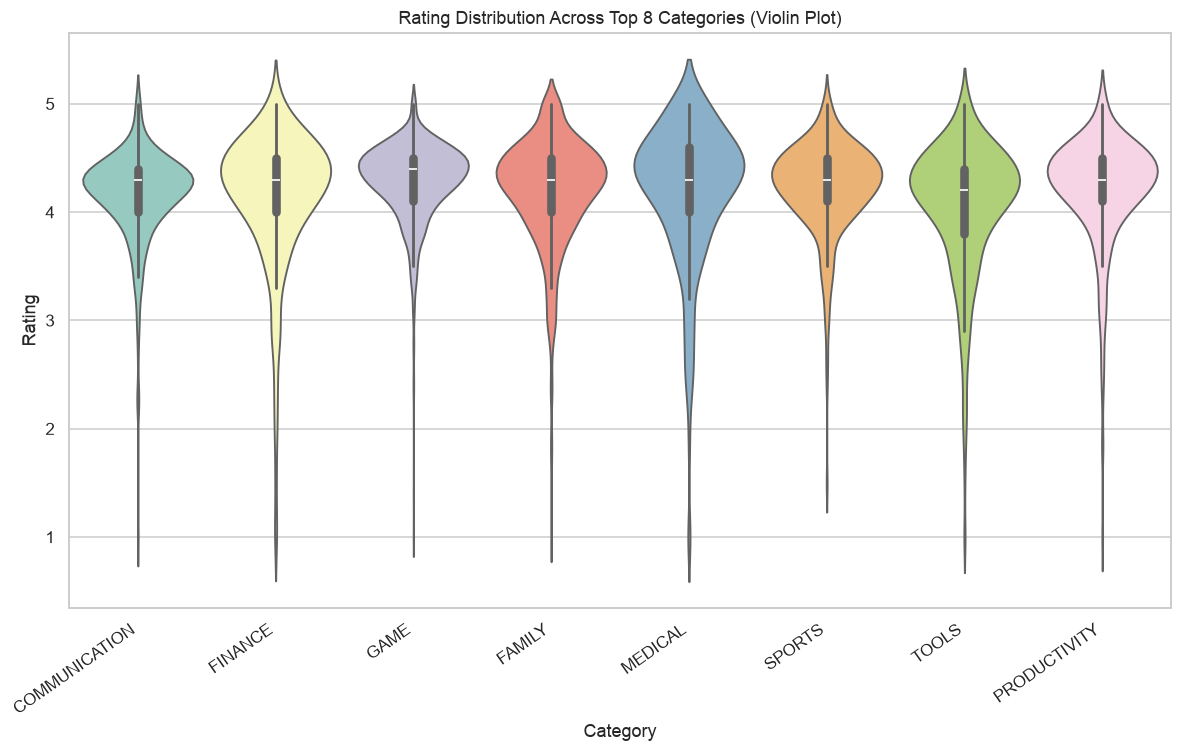

In [ ]:
# 18. Violin: Rating distribution across top 8 

plt.figure(figsize=(11,7))
top8 = df['Category'].value_counts().head(8).index
sns.violinplot(data=df[df['Category'].isin(top8)], x='Category', y='Rating', hue='Category',
               palette='Set3', legend=False)
plt.title('Rating Distribution Across Top 8 Categories (Violin Plot)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()

**Insight:** 

All top categories show the same basic shape that is a fat concentration of mass at 4.0-4.7 with a thin lower tail but `GAME` and `TOOLS` show visibly fatter low-rating tails than `FAMILY` or `PHOTOGRAPHY`, consistent with games/tools attracting more frustrated 1-2 star reviews (bugs, ads, crashes).

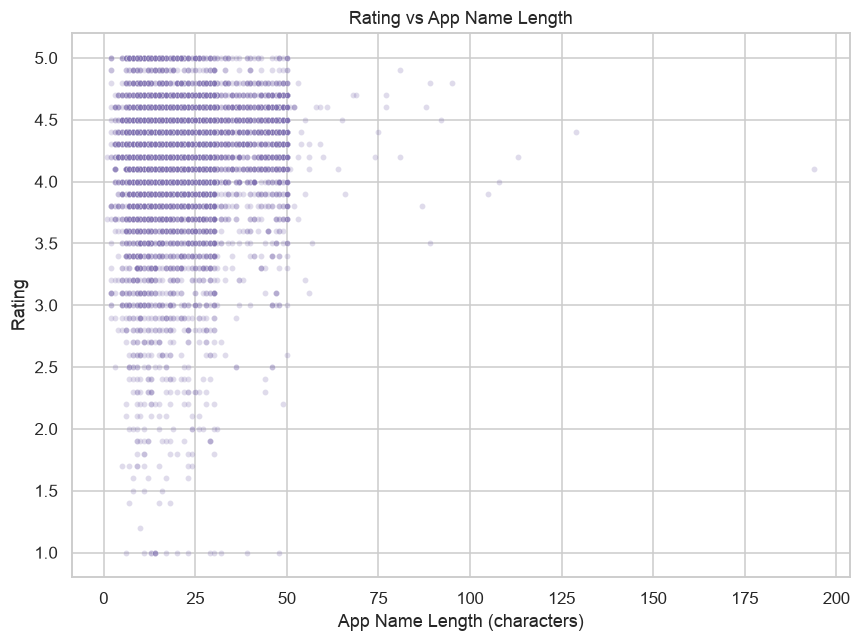

In [ ]:
# 19. App Name Length vs Rating

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='App_Name_Length', y='Rating', alpha=0.25, s=15, color='#8172B2')
plt.title('Rating vs App Name Length')
plt.xlabel('App Name Length (characters)'); plt.ylabel('Rating')
plt.tight_layout()

**Insight:** 

Longer app names (often keyword-stuffed for App Store Optimization, e.g. "Photo Editor & Candy Camera & Grid & ScrapBook") show a very weak positive correlation with rating (r≈0.14) — possibly because SEO-heavy names correlate with more actively marketed/maintained apps, not because the name itself matters.

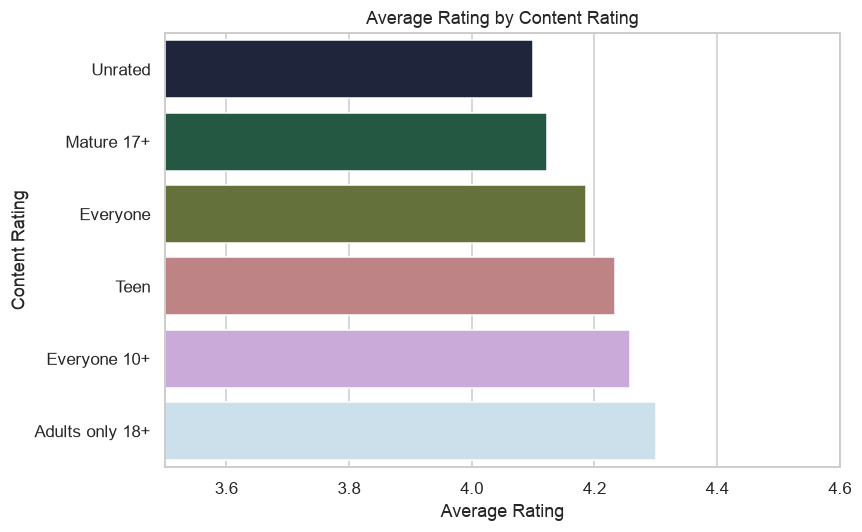

In [ ]:
# 20. Content Rating vs average Rating

plt.figure(figsize=(8,5))
cr_rating = df.groupby('Content Rating')['Rating'].mean().sort_values()
sns.barplot(x=cr_rating.values, y=cr_rating.index, hue=cr_rating.index, palette='cubehelix', legend=False)
plt.title('Average Rating by Content Rating')
plt.xlabel('Average Rating'); plt.ylabel('Content Rating')
plt.xlim(3.5,4.6)
plt.tight_layout()

**Insight:** 

**"Adults only 18+"** apps show the highest average rating (4.30) but this is based on a very small sample. Among the larger buckets, **"Everyone 10+" and "Teen"** apps (4.23 each) slightly outperform the general **"Everyone"** bucket (4.17), while **"Mature 17+" and "Unrated"** trail slightly — broader-audience apps face a wider range of expectations and thus somewhat lower average satisfaction.